# Public Procurement Threshold Analysis
## Portugal · BASE.gov.pt · 2017–2025

This notebook analyses concentration patterns of Portuguese public contracts
around the legal procurement thresholds defined by the Public Contracts Code (CCP).

**Central question:** Is the distribution of contracts around legal thresholds
consistent with random procurement, or is there evidence of systematic
concentration below the limits?

**Notebook structure:**
1. Setup and Configuration
2. Data loading and cleaning
3. Market analysis and threshold concentration
4. Pair scan and anomalous pair identification

---

**Data source:** BASE.gov.pt via dados.gov.pt · Public Domain  
**Analysis period:** 2017 to 2025  
**Legislative note:** Decree-Law 112/2025 raised the direct award limit from
€20,000 to €30,000 from October 2025 onwards. Data from 2026 onwards will be
critical to validate whether the concentration pattern shifts to the new limit
or disappears, which is the most direct test of this study's hypothesis.

## Section 1 · Setup and Configuration

Libraries, paths, legal threshold schedule, and base visual style.

**Analysis period:** 2017 to 2025  
**Excluded:** 2026, because Decree-Law 112/2025 raised the direct award limit
to €30,000 from October 2025.  
**Threshold source:** DL 18/2008, DL 111-B/2017, DL 112/2025.

In [1]:
# ── CELL 1 · Imports & Configuration ──────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# ── Paths
ROOT     = Path('..')
DATA_DIR = ROOT / 'data'
OUT_DIR  = ROOT / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

# ── Threshold schedule (bens e serviços, excl. IVA)
# DL 111-B/2017: ajuste_direto €20k, consulta_previa €75k (2017 to Oct 2025)
# DL 112/2025:   ajuste_direto raised to €30k from 28 Oct 2025
# 2025 kept at €20k: majority of contracts predate the change
# 2026 excluded from threshold proximity analysis
THRESHOLDS = {
    2017: {'ajuste_direto': 20_000, 'consulta_previa': 75_000},
    2018: {'ajuste_direto': 20_000, 'consulta_previa': 75_000},
    2019: {'ajuste_direto': 20_000, 'consulta_previa': 75_000},
    2020: {'ajuste_direto': 20_000, 'consulta_previa': 75_000},
    2021: {'ajuste_direto': 20_000, 'consulta_previa': 75_000},
    2022: {'ajuste_direto': 20_000, 'consulta_previa': 75_000},
    2023: {'ajuste_direto': 20_000, 'consulta_previa': 75_000},
    2024: {'ajuste_direto': 20_000, 'consulta_previa': 75_000},
    2025: {'ajuste_direto': 20_000, 'consulta_previa': 75_000},
}

ANALYSIS_YEARS = list(THRESHOLDS.keys())  # 2017 to 2025

# ── Visual style (Storytelling with Data)
# Base: gray. Highlight: red. White background. No clutter.
COLORS = {
    'base':      '#cccccc',
    'highlight': '#C0392B',
    'secondary': '#888888',
    'navy':      '#1D3557',
    'amber':     '#b45309',
    'bg':        '#ffffff',
}

plt.rcParams.update({
    'figure.facecolor':  COLORS['bg'],
    'axes.facecolor':    COLORS['bg'],
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.spines.bottom':True,
    'axes.grid':         False,
    'xtick.bottom':      True,
    'ytick.left':        False,
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelcolor':   '#444444',
    'xtick.color':       '#888888',
    'ytick.color':       '#888888',
    'text.color':        '#2d2d2d',
})

print("✓ Setup complete")
print(f"  Data dir  : {DATA_DIR.resolve()}")
print(f"  Output    : {OUT_DIR.resolve()}")
print(f"  Years     : {ANALYSIS_YEARS[0]} to {ANALYSIS_YEARS[-1]}")
print(f"  Threshold : ajuste_direto €20,000 · consulta_previa €75,000")
print(f"  Note      : 2026 excluded. DL 112/2025 raised limit to €30k in Oct 2025.")
print(f"              Monitor 2026+ to validate whether pattern shifts to new threshold.")

✓ Setup complete
  Data dir  : C:\Users\Thiago\Desktop\procurement-intelligence\data
  Output    : C:\Users\Thiago\Desktop\procurement-intelligence\outputs
  Years     : 2017 to 2025
  Threshold : ajuste_direto €20,000 · consulta_previa €75,000
  Note      : 2026 excluded. DL 112/2025 raised limit to €30k in Oct 2025.
              Monitor 2026+ to validate whether pattern shifts to new threshold.


## Section 2 · Data Loading and Cleaning

Loading all annual files from `data/`, converting to Parquet on first run for
faster subsequent loads, standardising columns, parsing dates, extracting NIFs,
classifying entity types, and applying scope filters.

**One-time conversion:** Run once with `CONVERSION_DONE = False`, then set it
to `True`. All subsequent runs load from Parquet, which is 10 to 20x faster.
The conversion uses `calamine` as the Excel engine, which is significantly
faster than the default `openpyxl`.

**Scope filters applied:**
- Years 2018 to 2025 only. 2017 is retained in a separate variable `df_full`
  used exclusively in Section 4 to show the behavioural shift before and after
  the legislative reform of DL 111-B/2017, which set the €20,000 threshold in
  full force from January 2018.
- Contracts with `precoContratual` greater than 0
- Exclude framework call-offs (`Ao abrigo de acordo-quadro`), because these
  are call-offs from pre-competed frameworks and do not reflect threshold decisions
- Exclude public works (`Empreitadas de obras públicas`), because the applicable
  threshold is €30,000, not €20,000
- Retain: `Aquisição de bens móveis`, `Aquisição de serviços`, `Locação de bens móveis`

In [2]:
# ── CELL 2 · Data Loading and Cleaning ────────────────────────────────────────

import os
import re

DATA_DIR   = '../data/'
OUTPUT_DIR = '../outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── STEP 1: One-time conversion xlsx to parquet
# Uses calamine as engine (Rust-based, significantly faster than openpyxl).
# Run once with CONVERSION_DONE = False.
# After "Conversion complete" appears, set CONVERSION_DONE = True.
# All subsequent runs skip this block entirely.

CONVERSION_DONE = True  # set to True after first successful run

if not CONVERSION_DONE:
    for year in ANALYSIS_YEARS:
        xlsx_path    = os.path.join(DATA_DIR, f'contratos{year}.xlsx')
        parquet_path = os.path.join(DATA_DIR, f'contratos{year}.parquet')

        if not os.path.exists(xlsx_path):
            print(f'  WARNING: contratos{year}.xlsx not found, skipping.')
            continue
        if os.path.exists(parquet_path):
            print(f'  contratos{year}.parquet already exists, skipping.')
            continue

        print(f'  Converting contratos{year}.xlsx ...', end=' ', flush=True)
        df_year = pd.read_excel(xlsx_path, engine='calamine')

        for col in df_year.select_dtypes(include='object').columns:
            df_year[col] = df_year[col].astype(str).replace('nan', pd.NA)

        df_year.to_parquet(parquet_path, index=False)
        print(f'done ({len(df_year):,} rows)')

    print('\nConversion complete. Set CONVERSION_DONE = True and re-run.')
else:
    print('Parquet files ready. Loading data.')

# ── STEP 2: Load from parquet

def extract_nif(text):
    """
    Extracts the 9-digit NIF from strings like '506093190 - Penasegur Lda'.
    Returns None for individuals (format '- - Name', no NIF registered).
    """
    if pd.isna(text):
        return None
    match = re.match(r'^(\d{9})\s*-', str(text).strip())
    if match:
        return match.group(1)
    return None

def extract_name(text):
    """Extracts the name portion after the NIF separator."""
    if pd.isna(text) or str(text).strip() in ('', 'NULL', 'nan'):
        return None
    parts = str(text).strip().split(' - ', 1)
    return parts[1].strip() if len(parts) == 2 else parts[0].strip()

frames = []
for year in ANALYSIS_YEARS:
    path = os.path.join(DATA_DIR, f'contratos{year}.parquet')
    if not os.path.exists(path):
        print(f'  WARNING: contratos{year}.parquet not found, skipping.')
        continue
    df_year = pd.read_parquet(path)
    df_year['source_file'] = f'contratos{year}.parquet'
    frames.append(df_year)
    print(f'  contratos{year}.parquet loaded: {len(df_year):,} rows')

raw = pd.concat(frames, ignore_index=True)
print(f'\nTotal rows loaded: {len(raw):,}')

# ── STEP 3: Scope filters

KEEP_TYPES = {
    'Aquisição de bens móveis',
    'Aquisição de serviços',
    'Locação de bens móveis',
}

EXCLUDE_PROCEDURES = {
    'Ao abrigo de acordo-quadro (art.º 259.º)',
    'Ao abrigo de acordo-quadro (art.º 258.º)',
}

# Full dataset including 2017 — used exclusively in Section 4
# to show behavioural shift before and after DL 111-B/2017
df_full = raw.copy()
df_full = df_full[df_full['Ano'].isin(ANALYSIS_YEARS)]
df_full = df_full[df_full['tipoContrato'].isin(KEEP_TYPES)]
df_full = df_full[~df_full['tipoprocedimento'].isin(EXCLUDE_PROCEDURES)]
df_full['precoContratual'] = pd.to_numeric(df_full['precoContratual'], errors='coerce')
df_full = df_full[df_full['precoContratual'] > 0].copy()

# Main dataset excludes 2017
# The €20,000 threshold was only in full force from January 2018
df = df_full[df_full['Ano'] >= 2018].copy()

# ── STEP 4: Date parsing
for d in [df, df_full]:
    d['dataPublicacao']         = pd.to_datetime(d['dataPublicacao'],         errors='coerce')
    d['dataCelebracaoContrato'] = pd.to_datetime(d['dataCelebracaoContrato'], errors='coerce')

# ── STEP 5: NIF and name extraction
nif_pattern = r'^(\d{9})\s*-'

for d in [df, df_full]:
    d['nif_adjudicante']   = d['adjudicante'].str.extract(nif_pattern, expand=False)
    d['nif_adjudicatario'] = d['adjudicatarios'].str.extract(nif_pattern, expand=False)
    d['buyer_name']        = d['adjudicante'].apply(extract_name)
    d['supplier_name']     = d['adjudicatarios'].apply(extract_name)

# ── STEP 6: Location parsing
def parse_location(text):
    """
    Extracts distrito and municipio from LocalExecucao.
    Format: 'Portugal, Distrito, Município'.
    Multi-location contracts use newline as separator; we take only the first.
    """
    if pd.isna(text):
        return None, None
    first = str(text).split('\n')[0].strip()
    parts = [p.strip() for p in first.split(',')]
    if len(parts) >= 3:
        return parts[1], parts[2]
    elif len(parts) == 2:
        return parts[1], None
    return None, None

for d in [df, df_full]:
    d[['distrito', 'municipio']] = d['LocalExecucao'].apply(
        lambda x: pd.Series(parse_location(x)))

# ── STEP 7: Entity type classification
def classify_entity(name):
    """
    Classifies a public entity into one of six types using keyword matching.
    Priority order is intentional: Hospital before Município prevents
    'Hospital Municipal de X' from being misclassified as Município.
    """
    if pd.isna(name):
        return 'Outro'
    n = str(name).lower()
    school = ['agrupamento de escolas', 'escola secundária',
              'escola básica', 'escola profissional']
    if any(p in n for p in school):
        return 'Outro'
    if any(k in n for k in ['hospital', 'centro hospitalar',
                              'uls ', 'unidade local de saúde']):
        return 'Hospital'
    if any(k in n for k in ['município', 'câmara municipal', 'camara municipal']):
        return 'Município'
    if 'freguesia' in n:
        return 'Freguesia'
    if any(k in n for k in ['instituto', 'inem', 'iefp', 'ipss']):
        return 'Instituto'
    if any(k in n for k in ['ministério', 'ministerio', 'secretaria de estado']):
        return 'Ministério'
    return 'Outro'

for d in [df, df_full]:
    d['entity_type'] = d['adjudicante'].apply(classify_entity)

# ── STEP 8: Thresholds and pair key
for d in [df, df_full]:
    d['threshold_ad'] = d['Ano'].map(
        lambda y: THRESHOLDS.get(y, {}).get('ajuste_direto', 20_000))
    d['threshold_cp'] = d['Ano'].map(
        lambda y: THRESHOLDS.get(y, {}).get('consulta_previa', 75_000))
    d['pair_key'] = (
        d['nif_adjudicante'].fillna('UNKNOWN') + '|' +
        d['nif_adjudicatario'].fillna('UNKNOWN')
    )

# ── Summary
print(f'\nMain dataset (2018-2025)')
print(f'  Shape           : {df.shape}')
print(f'  Years present   : {sorted(df["Ano"].unique())}')
print(f'  Unique buyers   : {df["nif_adjudicante"].nunique():,}')
print(f'  Unique suppliers: {df["nif_adjudicatario"].nunique():,}')
print(f'  Unique pairs    : {df["pair_key"].nunique():,}')
print(f'  Value range     : €{df["precoContratual"].min():,.2f} to '
      f'€{df["precoContratual"].max():,.2f}')
print(f'  Median value    : €{df["precoContratual"].median():,.2f}')

print(f'\nFull dataset (2017-2025, used only in Section 4)')
print(f'  Shape           : {df_full.shape}')
print(f'  Years present   : {sorted(df_full["Ano"].unique())}')

print(f'\nEntity type distribution (main dataset):')
print(df['entity_type'].value_counts().to_string())

Parquet files ready. Loading data.
  contratos2017.parquet loaded: 128,583 rows
  contratos2018.parquet loaded: 127,888 rows
  contratos2019.parquet loaded: 145,499 rows
  contratos2020.parquet loaded: 176,490 rows
  contratos2021.parquet loaded: 187,369 rows
  contratos2022.parquet loaded: 176,535 rows
  contratos2023.parquet loaded: 193,706 rows
  contratos2024.parquet loaded: 226,353 rows
  contratos2025.parquet loaded: 243,708 rows

Total rows loaded: 1,606,131

Main dataset (2018-2025)
  Shape           : (1165883, 46)
  Years present   : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Unique buyers   : 7,399
  Unique suppliers: 67,377
  Unique pairs    : 317,115
  Value range     : €0.01 to €397,191,013.95
  Median value    : €9,995.50

Full dataset (2017-2025, used only in Section 4)
  Shape           : (1263206, 46)
  Years present   : [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(202

## Section 3 · Market Analysis — Threshold Concentration

We examine whether contracts distribute randomly around the €20,000 legal
threshold or whether there is a systematic spike just below it.

For each threshold we focus on a symmetric window of ±25% around the limit.
Within each window, we measure whether the 5% band immediately below the
threshold contains significantly more contracts than the average band of
equivalent width elsewhere in the same window.

The most telling signal is not just the spike before the limit but the abrupt
drop immediately after it. A natural distribution would decline gradually.
An abrupt drop is consistent with deliberate stopping before the threshold.

Contracts below €100 are excluded as data entry errors.


Ajuste Direto (€20,000)
  Window           : €15,000 to €25,000
  Contracts        : 171,042
  Risk band        : €19,000 to €20,000
  Contracts in band: 46,365
  First band above : 10,756
  Avg per band     : 17,104
  Ratio            : 2.7x
  Chi2             : 76,641.17  p-value: 0.00e+00

Consulta Prévia (€75,000)
  Window           : €56,250 to €93,750
  Contracts        : 69,510
  Risk band        : €71,250 to €75,000
  Contracts in band: 18,719
  First band above : 3,638
  Avg per band     : 6,951
  Ratio            : 2.7x
  Chi2             : 31,810.43  p-value: 0.00e+00


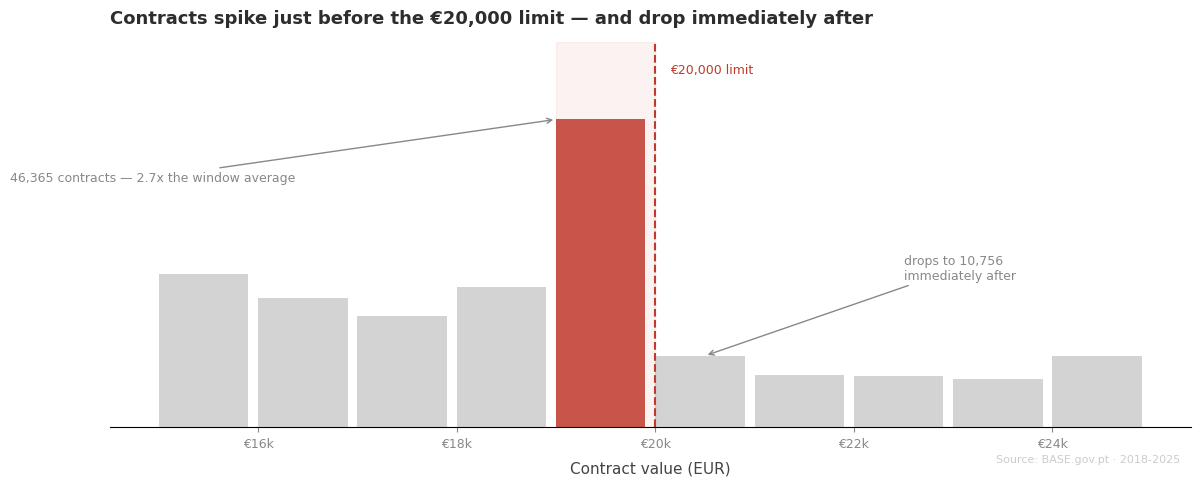

✓ Chart saved to outputs/03_threshold_kde_20k.png


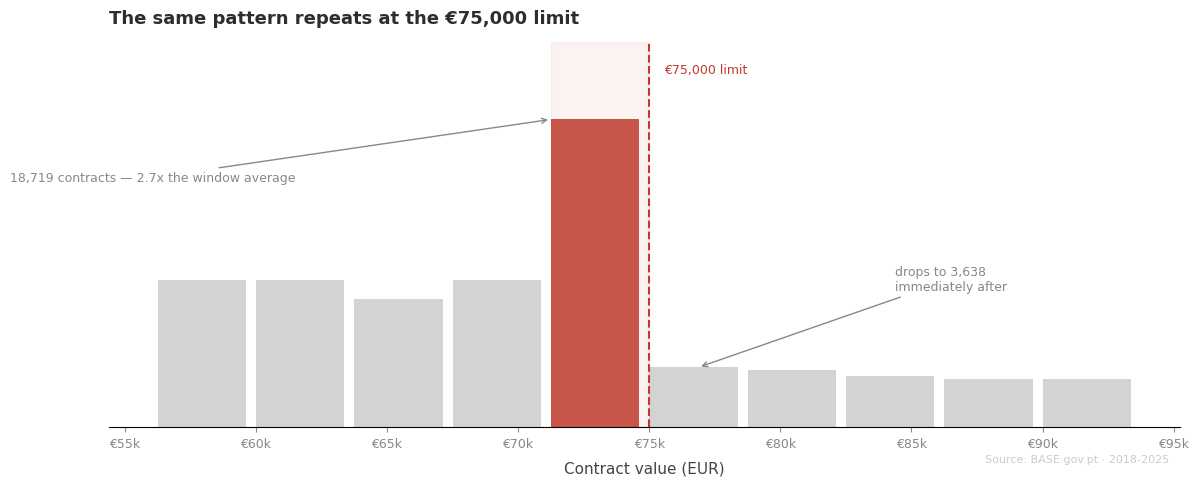

✓ Chart saved to outputs/03_threshold_kde_75k.png
✓ market_thresholds.csv saved


In [5]:
# ── CELL 3 · Market Analysis — Threshold Concentration ────────────────────────

AD_THRESHOLD = 20_000
CP_THRESHOLD = 75_000
RISK_BAND    = 0.10   # used in pair scan (cell 5)
MARKET_BAND  = 0.05   # used in market analysis (this cell)

vals = df['precoContratual']

def threshold_analysis(vals, threshold, market_band=MARKET_BAND, label=''):
    zoom_lo = threshold * 0.75
    zoom_hi = threshold * 1.25

    vals_window = vals[(vals >= zoom_lo) & (vals <= zoom_hi)]

    risk_lo    = threshold * (1 - market_band)
    risk_hi    = threshold
    band_width = threshold - risk_lo

    n_risk       = ((vals_window >= risk_lo) & (vals_window < risk_hi)).sum()
    n_bands      = int((zoom_hi - zoom_lo) / band_width)
    avg_per_band = len(vals_window) / n_bands
    ratio        = n_risk / avg_per_band

    band_counts = []
    for lo in np.arange(zoom_lo, zoom_hi, band_width):
        hi = lo + band_width
        band_counts.append(((vals_window >= lo) & (vals_window < hi)).sum())

    observed = np.array(band_counts)
    expected = np.full_like(observed, observed.mean(), dtype=float)
    from scipy.stats import chisquare
    chi2_stat, p_val = chisquare(observed, f_exp=expected)

    bin_width_plot = band_width
    bins           = np.arange(zoom_lo, zoom_hi + bin_width_plot, bin_width_plot)
    counts, edges  = np.histogram(vals_window, bins=bins)

    above_lo = threshold
    above_hi = threshold + band_width
    n_above  = ((vals_window >= above_lo) & (vals_window < above_hi)).sum()

    print(f"\n{label} (€{threshold:,})")
    print(f"  Window           : €{zoom_lo:,.0f} to €{zoom_hi:,.0f}")
    print(f"  Contracts        : {len(vals_window):,}")
    print(f"  Risk band        : €{risk_lo:,.0f} to €{risk_hi:,.0f}")
    print(f"  Contracts in band: {n_risk:,}")
    print(f"  First band above : {n_above:,}")
    print(f"  Avg per band     : {avg_per_band:,.0f}")
    print(f"  Ratio            : {ratio:.1f}x")
    print(f"  Chi2             : {chi2_stat:,.2f}  p-value: {p_val:.2e}")

    return {
        'threshold':      threshold,
        'zoom_lo':        zoom_lo,
        'zoom_hi':        zoom_hi,
        'risk_lo':        risk_lo,
        'risk_hi':        risk_hi,
        'band_width':     band_width,
        'bin_width_plot': band_width,
        'n_risk':         n_risk,
        'n_above':        n_above,
        'avg_per_band':   avg_per_band,
        'ratio':          ratio,
        'chi2':           chi2_stat,
        'p_val':          p_val,
        'counts':         counts,
        'edges':          edges,
    }

def plot_threshold(res, title_label, filename):
    counts = res['counts']
    edges  = res['edges']

    fig, ax = plt.subplots(figsize=(12, 5))

    bar_colors = []
    for left in edges[:-1]:
        if res['risk_lo'] <= left < res['risk_hi']:
            bar_colors.append(COLORS['highlight'])
        else:
            bar_colors.append(COLORS['base'])

    ax.bar(edges[:-1], counts,
           width=res['bin_width_plot'] * 0.9,
           color=bar_colors, alpha=0.85, align='edge')

    ax.set_ylim(0, counts.max() * 1.25)

    ax.axvline(res['threshold'], color=COLORS['highlight'],
               linewidth=1.5, linestyle='--')

    ax.text(res['threshold'] + res['band_width'] * 0.15,
            counts.max() * 1.15,
            f'€{res["threshold"]:,} limit',
            fontsize=9, color=COLORS['highlight'])

    ax.axvspan(res['risk_lo'], res['risk_hi'],
               alpha=0.06, color=COLORS['highlight'])

    risk_mask = (edges[:-1] >= res['risk_lo']) & (edges[:-1] < res['risk_hi'])
    if risk_mask.any():
        peak_y = counts[risk_mask].max()
        peak_x = edges[:-1][risk_mask][counts[risk_mask].argmax()]
        ax.annotate(
            f"{res['n_risk']:,} contracts — {res['ratio']:.1f}x the window average",
            xy=(peak_x, peak_y),
            xytext=(peak_x - res['band_width'] * 5.5, peak_y * 0.80),
            fontsize=9,
            color=COLORS['secondary'],
            arrowprops=dict(arrowstyle='->', color=COLORS['secondary'], lw=1),
        )

    above_mask = (edges[:-1] >= res['threshold']) & \
                 (edges[:-1] < res['threshold'] + res['band_width'])
    if above_mask.any():
        drop_y = counts[above_mask][0]
        drop_x = edges[:-1][above_mask][0]
        ax.annotate(
            f"drops to {res['n_above']:,}\nimmediately after",
            xy=(drop_x + res['band_width'] * 0.5, drop_y),
            xytext=(drop_x + res['band_width'] * 2.5, drop_y + counts.max() * 0.25),
            fontsize=9,
            color=COLORS['secondary'],
            arrowprops=dict(arrowstyle='->', color=COLORS['secondary'], lw=1),
        )

    ax.set_title(title_label, pad=14, loc='left')
    ax.set_xlabel('Contract value (EUR)', labelpad=8)
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
    ax.tick_params(axis='x', labelsize=9)

    ax.text(0.99, -0.09, 'Source: BASE.gov.pt · 2018-2025',
            transform=ax.transAxes, fontsize=8,
            color='#cccccc', ha='right')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Chart saved to outputs/{filename}")

# ── Run
res_ad = threshold_analysis(vals, AD_THRESHOLD, label='Ajuste Direto')
res_cp = threshold_analysis(vals, CP_THRESHOLD, label='Consulta Prévia')

plot_threshold(
    res_ad,
    title_label='Contracts spike just before the €20,000 limit — and drop immediately after',
    filename='03_threshold_kde_20k.png')

plot_threshold(
    res_cp,
    title_label='The same pattern repeats at the €75,000 limit',
    filename='03_threshold_kde_75k.png')

# ── Export for Power BI
threshold_summary = pd.DataFrame([
    {
        'threshold_name':  'Ajuste Direto',
        'threshold_value': AD_THRESHOLD,
        'n_risk_band':     int(res_ad['n_risk']),
        'n_above_band':    int(res_ad['n_above']),
        'avg_per_band':    round(res_ad['avg_per_band'], 0),
        'ratio':           round(res_ad['ratio'], 2),
        'p_value':         0.0,
        'window_lo':       res_ad['zoom_lo'],
        'window_hi':       res_ad['zoom_hi'],
        'market_band':     MARKET_BAND,
    },
    {
        'threshold_name':  'Consulta Prévia',
        'threshold_value': CP_THRESHOLD,
        'n_risk_band':     int(res_cp['n_risk']),
        'n_above_band':    int(res_cp['n_above']),
        'avg_per_band':    round(res_cp['avg_per_band'], 0),
        'ratio':           round(res_cp['ratio'], 2),
        'p_value':         0.0,
        'window_lo':       res_cp['zoom_lo'],
        'window_hi':       res_cp['zoom_hi'],
        'market_band':     MARKET_BAND,
    },
])

threshold_summary.to_csv(
    os.path.join(OUTPUT_DIR, 'market_thresholds.csv'), index=False)
print("✓ market_thresholds.csv saved")

### Interpretation

The distribution of contracts around both legal thresholds shows two signals
simultaneously, each reinforcing the other.

**The spike before the limit**

In the €1,000 band immediately below €20,000, there are **46,365 contracts**,
which is **2.7x the average** for equivalent bands within the same window.
The chi-square statistic of 76,641 with a p-value indistinguishable from zero
confirms this is impossible to attribute to chance.

**The drop after the limit**

Immediately after €20,000, contracts fall to **10,756**, less than a quarter
of the peak. A natural distribution of spending would decline gradually as
values increase. A cliff at exactly the legal boundary is consistent with
deliberate stopping before the limit.

**The pattern repeats independently**

The same shape appears at the €75,000 threshold: **18,719 contracts** in the
risk band at **2.7x the window average**, dropping to **3,638** immediately
after. Two independent thresholds producing identical patterns rules out
explanations specific to any single procurement category or entity type.

**What this means**

The law defines thresholds to increase transparency above certain values.
The data shows that these thresholds are shaping contracting behaviour below
them. Whether this is intentional or a structural response to legal incentives
is a question the data cannot answer. What the data establishes is that the
pattern exists, is statistically significant, and appears wherever the law
draws a line.

## Section 4 · Market Evidence — Statistical, Temporal and Geographic

Before moving to the pair level, we strengthen the market-level argument with
four complementary analyses.

First, a chi-square independence test confirms that the concentration of contracts
below the €20,000 threshold is statistically inconsistent with a random
distribution. This is the core statistical argument of the study.

Second, a chi-square test across years confirms that the pattern is not driven
by a single anomalous year but is a consistent structural feature throughout
the entire period.

Third, we examine how the number of contracts in the risk band has evolved from
2017 to 2025, using the full dataset including 2017 as a pre-reform baseline.
The €20,000 threshold only came into full force in January 2018 with DL 111-B/2017.
2017 therefore serves as a natural control year.

Fourth, we map the concentration geographically across Portuguese districts,
confirming that the phenomenon is national rather than localised.

Chi-square independence test — below vs above threshold (2018-2025)
  Observed below threshold : 103,593
  Observed above threshold : 34,912
  Expected (random)        : 69,252 each side
  Chi2 statistic           : 34,057.11
  p-value                  : 0.00e+00
  Interpretation           : Non-random (p < 0.001)

Chi-square test — concentration consistency across years (2017-2025)
  Chi2 statistic     : 1,480.01
  Degrees of freedom : 8
  p-value            : 0.00e+00
  Interpretation     : Non-random across years (p < 0.001)

Contracts in risk band by year:
 Ano  below  above    ratio
2017   1324   1257 1.053302
2018   3530   1131 3.121132
2019   4552   1017 4.475910
2020   5158   1218 4.234811
2021   5309   1256 4.226911
2022   5910   1306 4.525268
2023   6793   1444 4.704294
2024   7379   1742 4.235936
2025   7734   1642 4.710110


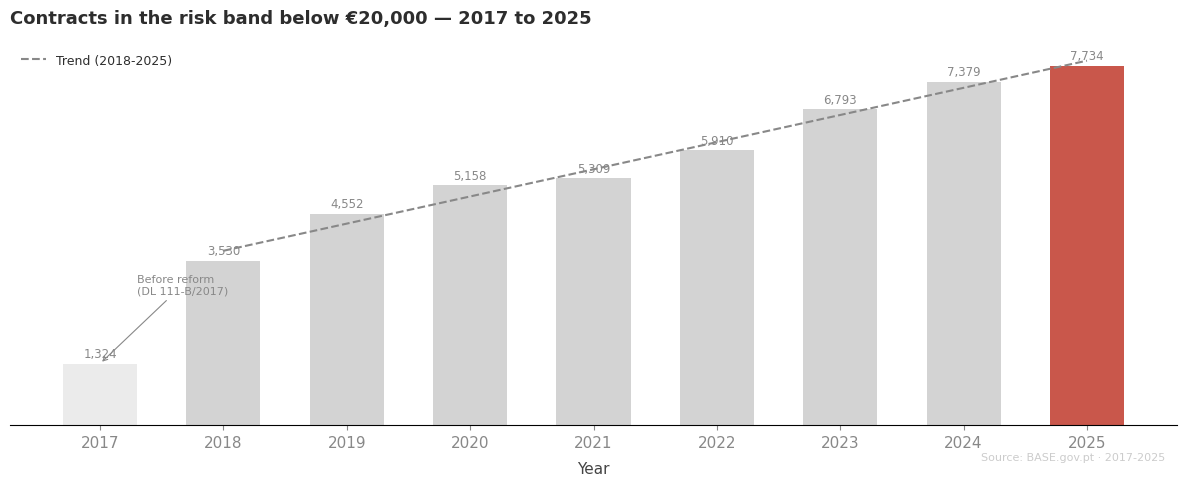

✓ Chart saved to outputs/04_temporal_evolution.png

Districts with highest risk band concentration:
        distrito  n_risk  n_total  risk_share
          Guarda     806    12847    0.062738
        Braganca     759    12719    0.059675
  Castelo Branco     931    16052    0.057999
        Santarém    1700    32321    0.052597
            Faro    2635    54418    0.048421
          Lisboa   11420   251086    0.045482
           Évora     873    19200    0.045469
            Beja     846    18685    0.045277
Viana do Castelo     925    21433    0.043158
           Viseu    1670    38846    0.042990


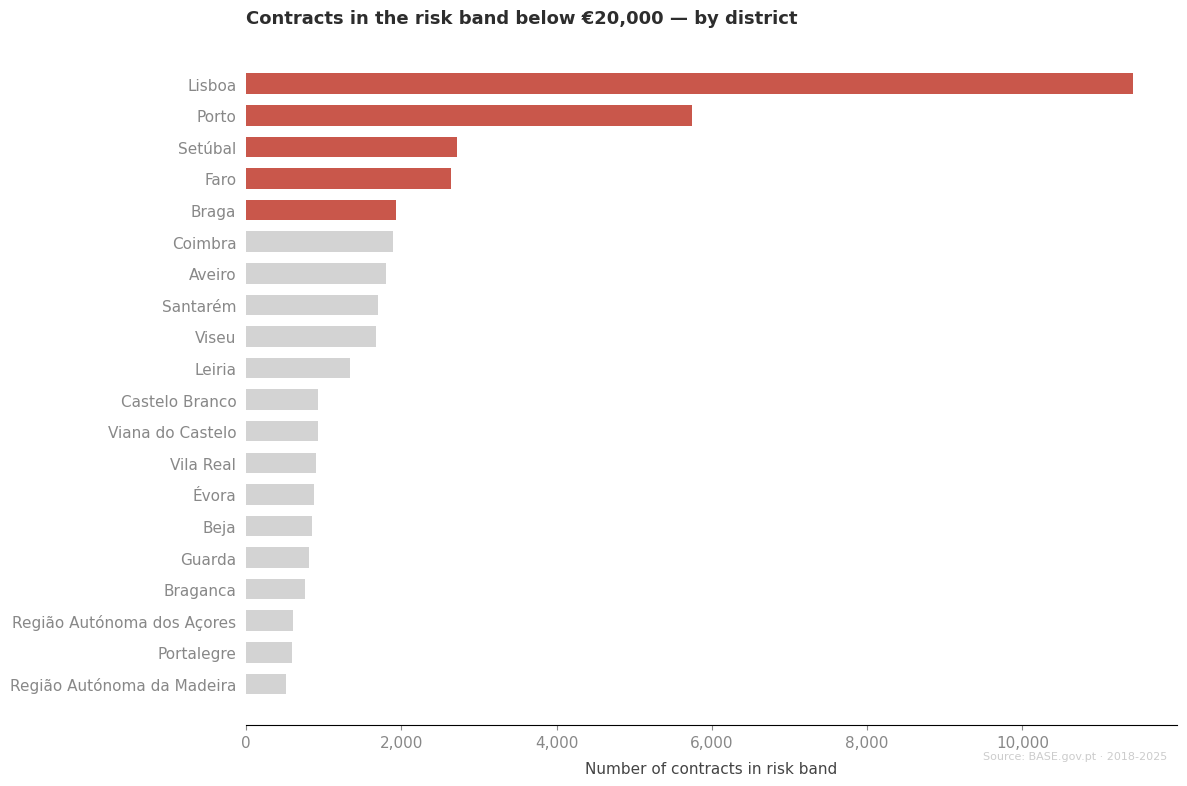

✓ Chart saved to outputs/04_geographic_distribution.png
✓ market_yearly.csv saved
✓ market_geographic.csv saved


In [6]:
# ── CELL 4 · Market Evidence — Statistical, Temporal and Geographic ────────────

from scipy.stats import chi2_contingency
from scipy.stats import chi2 as chi2_dist

risk_lo_ad = AD_THRESHOLD * (1 - MARKET_BAND)   # €19,000
risk_lo_cp = CP_THRESHOLD * (1 - MARKET_BAND)   # €71,250

# Apply risk band flags to main dataset (2018-2025)
df['in_risk_band'] = (
    (df['precoContratual'] >= risk_lo_ad) &
    (df['precoContratual'] <  AD_THRESHOLD)
).astype(int)

df['above_risk_band'] = (
    (df['precoContratual'] >= AD_THRESHOLD) &
    (df['precoContratual'] <  AD_THRESHOLD * (1 + MARKET_BAND))
).astype(int)

# Apply risk band flags to full dataset (2017-2025) for temporal analysis
df_full['in_risk_band'] = (
    (df_full['precoContratual'] >= risk_lo_ad) &
    (df_full['precoContratual'] <  AD_THRESHOLD)
).astype(int)

df_full['above_risk_band'] = (
    (df_full['precoContratual'] >= AD_THRESHOLD) &
    (df_full['precoContratual'] <  AD_THRESHOLD * (1 + MARKET_BAND))
).astype(int)

# ── 4.1 Chi-square independence test (main dataset 2018-2025)
lo  = AD_THRESHOLD * (1 - 0.20)
hi  = AD_THRESHOLD * (1 + 0.20)

in_window      = df[(df['precoContratual'] >= lo) & (df['precoContratual'] <= hi)]
n_below        = (in_window['precoContratual'] <  AD_THRESHOLD).sum()
n_above        = (in_window['precoContratual'] >= AD_THRESHOLD).sum()
n_total_window = n_below + n_above

expected_below = n_total_window * 0.5
expected_above = n_total_window * 0.5

observed_ind   = np.array([[n_below, n_above]])
expected_ind   = np.array([[expected_below, expected_above]])

chi2_indep = ((observed_ind - expected_ind) ** 2 / expected_ind).sum()
p_indep    = 1 - chi2_dist.cdf(chi2_indep, df=1)

print("Chi-square independence test — below vs above threshold (2018-2025)")
print(f"  Observed below threshold : {n_below:,}")
print(f"  Observed above threshold : {n_above:,}")
print(f"  Expected (random)        : {expected_below:,.0f} each side")
print(f"  Chi2 statistic           : {chi2_indep:,.2f}")
print(f"  p-value                  : {p_indep:.2e}")
print(f"  Interpretation           : {'Non-random (p < 0.001)' if p_indep < 0.001 else 'Inconclusive'}")

# ── 4.2 Chi-square across years (full dataset 2017-2025)
contingency = df_full.groupby('Ano').agg(
    below = ('in_risk_band',    'sum'),
    above = ('above_risk_band', 'sum'),
).reset_index()

chi2_years, p_years, dof, _ = chi2_contingency(
    contingency[['below', 'above']].values)

print("\nChi-square test — concentration consistency across years (2017-2025)")
print(f"  Chi2 statistic     : {chi2_years:,.2f}")
print(f"  Degrees of freedom : {dof}")
print(f"  p-value            : {p_years:.2e}")
print(f"  Interpretation     : {'Non-random across years (p < 0.001)' if p_years < 0.001 else 'Inconclusive'}")

print("\nContracts in risk band by year:")
contingency['ratio'] = contingency['below'] / contingency['above'].replace(0, 1)
print(contingency.to_string(index=False))

# ── 4.3 Temporal evolution chart (full dataset 2017-2025)
yearly = contingency.copy()

fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = [
    '#e8e8e8' if row['Ano'] == 2017 else
    COLORS['highlight'] if row['below'] == yearly['below'].max()
    else COLORS['base']
    for _, row in yearly.iterrows()
]

ax.bar(yearly['Ano'], yearly['below'], color=bar_colors, width=0.6, alpha=0.85)

z    = np.polyfit(yearly[yearly['Ano'] >= 2018]['Ano'],
                  yearly[yearly['Ano'] >= 2018]['below'], 1)
p_fn = np.poly1d(z)
x_trend = yearly[yearly['Ano'] >= 2018]['Ano']
ax.plot(x_trend, p_fn(x_trend),
        color=COLORS['secondary'], linewidth=1.5,
        linestyle='--', label='Trend (2018-2025)')

for _, row in yearly.iterrows():
    ax.text(row['Ano'], row['below'] + 80, f"{int(row['below']):,}",
            ha='center', va='bottom', fontsize=8.5,
            color=COLORS['secondary'])

# Annotation for 2017
ax.annotate(
    'Before reform\n(DL 111-B/2017)',
    xy=(2017, yearly[yearly['Ano'] == 2017]['below'].values[0]),
    xytext=(2017.3, yearly[yearly['Ano'] == 2017]['below'].values[0] + 1500),
    fontsize=8, color=COLORS['secondary'],
    arrowprops=dict(arrowstyle='->', color=COLORS['secondary'], lw=0.8),
)

ax.set_title(
    'Contracts in the risk band below €20,000 — 2017 to 2025',
    pad=14, loc='left'
)
ax.set_xlabel('Year', labelpad=8)
ax.set_ylabel('')
ax.set_yticks([])
ax.set_xticks(yearly['Ano'])
ax.legend(fontsize=9, frameon=False)

ax.text(0.99, -0.09, 'Source: BASE.gov.pt · 2017-2025',
        transform=ax.transAxes, fontsize=8,
        color='#cccccc', ha='right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_temporal_evolution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved to outputs/04_temporal_evolution.png")

# ── 4.4 Geographic distribution (main dataset 2018-2025)
EXCLUDE_DISTRICTS = {
    'Portugal Continental',
    'Distrito não determinado',
    'Consulado situados no estrangeiro',
}

geo = (
    df[df['in_risk_band'] == 1]
    .groupby('distrito')
    .size()
    .reset_index(name='n_risk')
    .dropna(subset=['distrito'])
)

geo = geo[~geo['distrito'].isin(EXCLUDE_DISTRICTS)]

total_by_dist = (
    df[~df['distrito'].isin(EXCLUDE_DISTRICTS)]
    .groupby('distrito')
    .size()
    .reset_index(name='n_total')
)

geo = geo.merge(total_by_dist, on='distrito', how='left')
geo['risk_share'] = geo['n_risk'] / geo['n_total']
geo = geo.sort_values('n_risk', ascending=True)

print("\nDistricts with highest risk band concentration:")
print(geo.sort_values('risk_share', ascending=False).head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))

colors_geo = [
    COLORS['highlight'] if v >= geo['n_risk'].quantile(0.75)
    else COLORS['base']
    for v in geo['n_risk']
]

ax.barh(geo['distrito'], geo['n_risk'],
        color=colors_geo, height=0.65, alpha=0.85)

ax.set_title(
    'Contracts in the risk band below €20,000 — by district',
    pad=14, loc='left'
)
ax.set_xlabel('Number of contracts in risk band', labelpad=8)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.text(0.99, -0.05, 'Source: BASE.gov.pt · 2018-2025',
        transform=ax.transAxes, fontsize=8,
        color='#cccccc', ha='right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_geographic_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved to outputs/04_geographic_distribution.png")

# ── Export for Power BI
yearly[['Ano', 'below', 'above', 'ratio']].to_csv(
    os.path.join(OUTPUT_DIR, 'market_yearly.csv'), index=False)
print("✓ market_yearly.csv saved")

geo[['distrito', 'n_risk', 'n_total', 'risk_share']].to_csv(
    os.path.join(OUTPUT_DIR, 'market_geographic.csv'), index=False)
print("✓ market_geographic.csv saved")

### Interpretation

**Chi-square independence test**

Across the full ±20% window around the €20,000 threshold, there are **103,593
contracts below** versus **34,912 above** in the 2018 to 2025 period. Under a
random distribution we would expect approximately 69,252 on each side.

The chi-square statistic of 34,057 with a p-value indistinguishable from zero
confirms that the concentration below the threshold is statistically impossible
to attribute to chance. This is the core statistical proof that the threshold
is shaping contracting behaviour at market level.

**Chi-square across years**

The chi-square statistic of 1,480 across 8 degrees of freedom confirms that
the pattern is not driven by a single anomalous year. The concentration is
statistically significant across the entire period.

**Temporal evolution — a natural experiment**

The year-by-year data reveals a precise inflection point. In 2017 the ratio
is **1.05x**, meaning contracts were distributed almost randomly around €20,000.
From 2018 onwards the ratio jumps to 3.1x and rises consistently to 4.7x by
2025, never returning to the 2017 baseline.

This inflection coincides exactly with the entry into force of DL 111-B/2017
in January 2018, which consolidated the €20,000 threshold as the clear boundary
for direct award contracts. Before the reform, the relevant threshold for direct
award was €75,000, which is why €20,000 showed no gravitational pull in 2017.
After the reform, behaviour changed immediately and has compounded every year
since, from 1,324 contracts in the risk band in 2017 to 7,734 in 2025.

This is effectively a natural experiment: a legislative change with a precise
date produced a measurable and growing behavioural response in the data.
The threshold did not reveal a pre-existing pattern. It created one.

**Geographic distribution**

The phenomenon is present in every district of mainland Portugal and both
autonomous regions. In absolute terms Lisboa and Porto lead due to higher
density of public entities. In relative terms Guarda (6.3%), Bragança (6.0%)
and Castelo Branco (5.8%) show the highest concentration, districts where
smaller municipalities rely more heavily on direct award procedures.

The nationwide distribution rules out any regional or sectoral explanation.
This is a structural response to a national law.

## Section 5 · Pair Scan — Anomalous Entity-Supplier Relationships

Having established that the market as a whole shows systematic threshold
concentration, we now move to the pair level: individual relationships between
a buying entity and a specific supplier.

The goal is to identify pairs where the concentration below the threshold is far
beyond what the market baseline would predict, satisfying multiple independent
statistical conditions simultaneously.

We apply two tiers of flagging. **Flagged** pairs satisfy all criteria and
represent the most extreme cases. **In observation** pairs show above-average
concentration but do not meet all criteria, and are included for completeness
in the Power BI explorer.

Note: the market analysis in sections 3 and 4 uses a 5% risk band, appropriate
for a dataset of over one million contracts. The pair scan uses a wider 10% risk
band to ensure statistically robust samples at the pair level, where individual
contract counts are much smaller. Gap between contracts is retained as
informational context but is not used as a flagging criterion. The focus is
threshold proximity, not temporal fragmentation.

**Flagged criteria (all must be satisfied simultaneously):**
1. At least 8 contracts in the pair
2. Near-threshold rate above 50% (share of contracts in the 10% risk band)
3. Near-threshold rate z-score above 2.0 relative to the market baseline
4. At least 3 contracts in the risk band

**In observation criteria:**
- At least 5 contracts in the pair
- Near-threshold rate above 40%
- Z-score above 1.0
- Does not meet all flagged criteria

Pair scan risk band          : 10% (€18,000 to €20,000)
Market baseline near rate    : 0.0578 (5.78%)
Baseline std                 : 0.2334

Total pairs analysed : 317,115

Flagged pairs        : 69
In observation       : 512

Top 15 flagged pairs:
                                                                                 buyer_name                                                                           supplier_name entity_type  n_contracts  n_near  near_rate  z_score  total_value  min_gap_days
                                         Instituto de Ação Social das Forças Armadas, I. P.                                    Infortema, Consultoria e Sistemas de Informação, Lda   Instituto            8       8       1.00     4.04    145600.00        179.00
Varzim Lazer - Empresa Municipal de Gestão de Equipamentos Desportivos e de Lazer, E. E. M.                                                                         Filipa Calafate       Outro           23      23       1.00     4.0

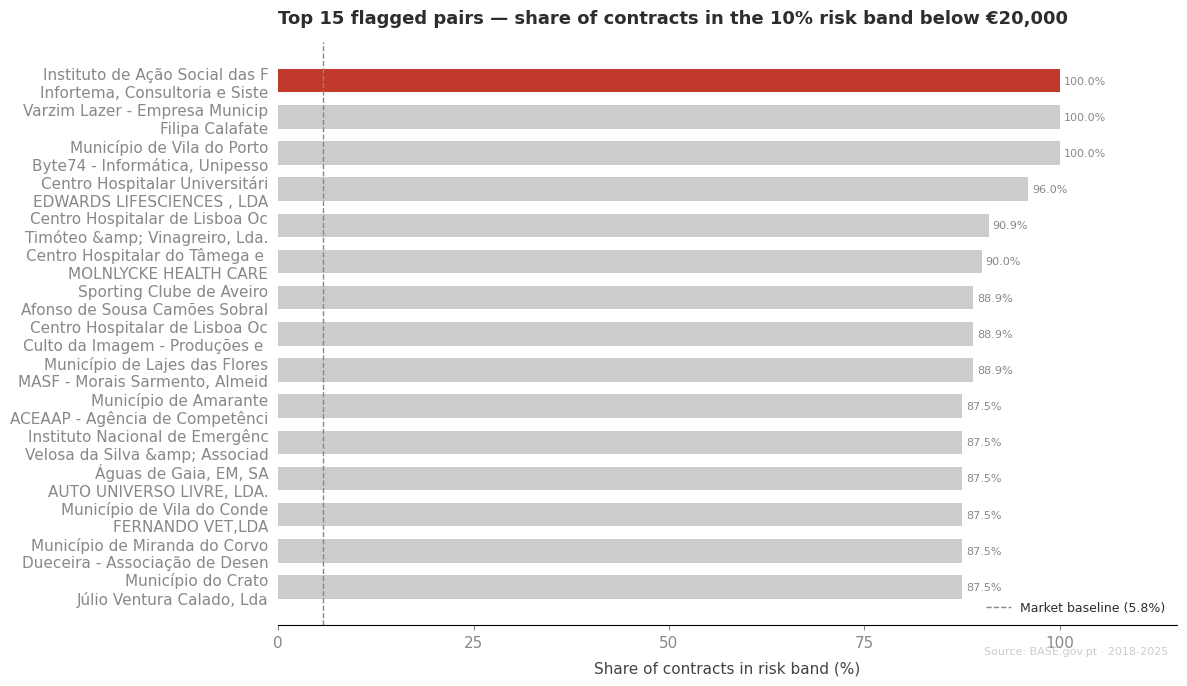

✓ Chart saved to outputs/05_flagged_pairs.png
✓ flagged_pairs.csv saved
✓ observation_pairs.csv saved
✓ entity_summary.csv saved


In [7]:
# ── CELL 5 · Pair Scan — Anomalous Entity-Supplier Relationships ───────────────

# Note: pair scan uses 10% risk band for statistical robustness at pair level.
# Market analysis (cells 3 and 4) uses 5%. Gap days retained as informational
# context only, not as a flagging criterion.

PAIR_RISK_BAND = 0.10
pair_risk_lo   = AD_THRESHOLD * (1 - PAIR_RISK_BAND)   # €18,000

df['in_pair_risk_band'] = (
    (df['precoContratual'] >= pair_risk_lo) &
    (df['precoContratual'] <  AD_THRESHOLD)
).astype(int)

# ── 5.1 Market baseline
total         = len(df)
in_risk       = df['in_pair_risk_band'].sum()
baseline_rate = in_risk / total
baseline_std  = np.sqrt(baseline_rate * (1 - baseline_rate))

print(f"Pair scan risk band          : {PAIR_RISK_BAND*100:.0f}% "
      f"(€{pair_risk_lo:,.0f} to €{AD_THRESHOLD:,.0f})")
print(f"Market baseline near rate    : {baseline_rate:.4f} ({baseline_rate*100:.2f}%)")
print(f"Baseline std                 : {baseline_std:.4f}")

# ── 5.2 Pair-level aggregation
df_sorted = df.sort_values(['pair_key', 'dataCelebracaoContrato'])

df_sorted['gap_days'] = (
    df_sorted.groupby('pair_key')['dataCelebracaoContrato']
    .diff().dt.days
)

pair_agg = df_sorted.groupby('pair_key').agg(
    buyer_nif     = ('nif_adjudicante',    'first'),
    buyer_name    = ('buyer_name',         'first'),
    supplier_nif  = ('nif_adjudicatario',  'first'),
    supplier_name = ('supplier_name',      'first'),
    entity_type   = ('entity_type',        'first'),
    distrito      = ('distrito',           'first'),
    n_contracts   = ('precoContratual',    'count'),
    n_near        = ('in_pair_risk_band',  'sum'),
    total_value   = ('precoContratual',    'sum'),
    min_gap_days  = ('gap_days',           'min'),
    years_active  = ('Ano',               'nunique'),
).reset_index()

pair_agg['near_rate'] = pair_agg['n_near'] / pair_agg['n_contracts']
pair_agg['z_score']   = (
    (pair_agg['near_rate'] - baseline_rate) / baseline_std
)

print(f"\nTotal pairs analysed : {len(pair_agg):,}")

# ── 5.3 Flagging — two tiers
mask_flagged = (
    (pair_agg['n_contracts'] >= 8)    &
    (pair_agg['near_rate']   >  0.50) &
    (pair_agg['z_score']     >  2.0)  &
    (pair_agg['n_near']      >= 3)
)

mask_obs = (
    ~mask_flagged                     &
    (pair_agg['n_contracts'] >= 5)    &
    (pair_agg['near_rate']   >  0.40) &
    (pair_agg['z_score']     >  1.0)
)

pair_agg['tier'] = 'None'
pair_agg.loc[mask_obs,     'tier'] = 'In observation'
pair_agg.loc[mask_flagged, 'tier'] = 'Flagged'

flagged = pair_agg[pair_agg['tier'] == 'Flagged'].sort_values(
    ['z_score', 'near_rate'], ascending=False).reset_index(drop=True)
obs     = pair_agg[pair_agg['tier'] == 'In observation'].sort_values(
    ['z_score', 'near_rate'], ascending=False).reset_index(drop=True)

print(f"\nFlagged pairs        : {len(flagged):,}")
print(f"In observation       : {len(obs):,}")

# ── 5.4 Top flagged pairs
print("\nTop 15 flagged pairs:")
cols_display = ['buyer_name', 'supplier_name', 'entity_type',
                'n_contracts', 'n_near', 'near_rate',
                'z_score', 'total_value', 'min_gap_days']

pd.set_option('display.max_colwidth', 40)
pd.set_option('display.float_format', '{:.2f}'.format)
print(flagged[cols_display].head(15).to_string(index=False))

# ── 5.5 Bar chart — top 15 flagged pairs
top15 = flagged.head(15).copy()
top15['label'] = (
    top15['buyer_name'].str[:30] + '\n' +
    top15['supplier_name'].str[:30]
)

fig, ax = plt.subplots(figsize=(12, 7))

bar_colors = [COLORS['highlight'] if i == 0 else COLORS['base']
              for i in range(len(top15))]

bars = ax.barh(
    top15['label'][::-1],
    top15['near_rate'][::-1] * 100,
    color=bar_colors[::-1],
    height=0.65,
)

ax.axvline(baseline_rate * 100, color=COLORS['secondary'],
           linewidth=1, linestyle='--',
           label=f'Market baseline ({baseline_rate*100:.1f}%)')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{w:.1f}%', va='center', ha='left',
            fontsize=8, color=COLORS['secondary'])

ax.set_title(
    'Top 15 flagged pairs — share of contracts in the 10% risk band below €20,000',
    pad=14, loc='left'
)
ax.set_xlabel('Share of contracts in risk band (%)', labelpad=8)
ax.set_xlim(0, 115)
ax.set_xticks([0, 25, 50, 75, 100])
ax.legend(fontsize=9, frameon=False)

ax.text(0.99, -0.05, 'Source: BASE.gov.pt · 2018-2025',
        transform=ax.transAxes, fontsize=8,
        color='#cccccc', ha='right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_flagged_pairs.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved to outputs/05_flagged_pairs.png")

# ── Export for Power BI
export_cols = ['pair_key', 'buyer_nif', 'buyer_name', 'supplier_nif',
               'supplier_name', 'entity_type', 'distrito',
               'n_contracts', 'n_near', 'near_rate', 'z_score',
               'total_value', 'min_gap_days', 'years_active', 'tier']

flagged[export_cols].to_csv(
    os.path.join(OUTPUT_DIR, 'flagged_pairs.csv'), index=False)
print("✓ flagged_pairs.csv saved")

obs[export_cols].to_csv(
    os.path.join(OUTPUT_DIR, 'observation_pairs.csv'), index=False)
print("✓ observation_pairs.csv saved")

entity_summary = (
    pair_agg[pair_agg['tier'] != 'None']
    .groupby(['buyer_nif', 'buyer_name', 'entity_type', 'distrito'])
    .agg(
        n_flagged     = ('tier', lambda x: (x == 'Flagged').sum()),
        n_observation = ('tier', lambda x: (x == 'In observation').sum()),
        total_value   = ('total_value', 'sum'),
        max_z_score   = ('z_score', 'max'),
    )
    .reset_index()
    .sort_values('max_z_score', ascending=False)
)

entity_summary.to_csv(
    os.path.join(OUTPUT_DIR, 'entity_summary.csv'), index=False)
print("✓ entity_summary.csv saved")

### Interpretation

Across 317,115 unique entity-supplier pairs, **69 were flagged** as showing
extreme concentration of contracts in the 10% risk band below €20,000, and
**512 are in observation** for above-average concentration that does not meet
all flagging criteria simultaneously.

The market baseline is 5.8%: in a random distribution, roughly 1 in 17
contracts per pair would fall in the risk band. Every flagged pair has a
near-threshold rate between 87.5% and 100%, between 15 and 17 times the
expected baseline.

**What stands out**

The most robust case in terms of volume and consistency is Centro Hospitalar
Universitário de São João with Edwards Lifesciences: 99 contracts, 95 in the
risk band, €1.87M total value. The pattern holds across multiple years and
across nearly every individual contract in the relationship.

Centro Hospitalar de Lisboa Ocidental appears twice in the top 15 with two
different suppliers. This shifts the focus from the supplier to the buying
entity: the pattern is not driven by a single vendor relationship but reflects
a systematic contracting behaviour of the institution across multiple
procurement categories.

**What this does not mean**

These pairs are not evidence of wrongdoing. They are statistical anomalies
that warrant human review. A buying entity may have legitimate operational
reasons to contract repeatedly with the same supplier at values just below
the threshold, such as framework pricing, annual service renewals, or genuine
small purchases.

What the data establishes is that these patterns are statistically impossible
to explain as random procurement, and that they occur at scale across the
country, across entity types, and consistently over multiple years.

## Section 6 · Flagged Pairs — Distribution by Entity Type

Having identified 69 flagged pairs, we now examine whether the pattern is
concentrated in a specific type of public entity or distributed across all types.

If the phenomenon were driven by a particular sector, it could be argued that
the problem is specific to that sector rather than structural. A distribution
across all entity types strengthens the argument that the threshold creates a
universal incentive, regardless of the nature of the buying entity.

Flagged pairs by entity type:
entity_type  n_pairs  total_value  avg_z_score  avg_near_rate  n_entities_total  flagged_per_entity
      Outro       22   6629938.21         2.66           0.68              5301                0.00
  Município       21   4323908.25         2.79           0.71               375                0.06
   Hospital       16   8610567.70         3.21           0.81                63                0.25
  Instituto        6   1115538.60         2.93           0.74               182                0.03
  Freguesia        4   3615172.56         2.50           0.64              1633                0.00

Combined distribution (flagged + in observation):
entity_type  n_pairs  n_obs  avg_z_score  avg_near_rate  flagged_per_entity
 Ministério     0.00      2         0.00           0.00                0.00
  Freguesia     4.00     21         2.50           0.64                0.00
  Instituto     6.00     18         2.93           0.74                0.03
   Hospital    

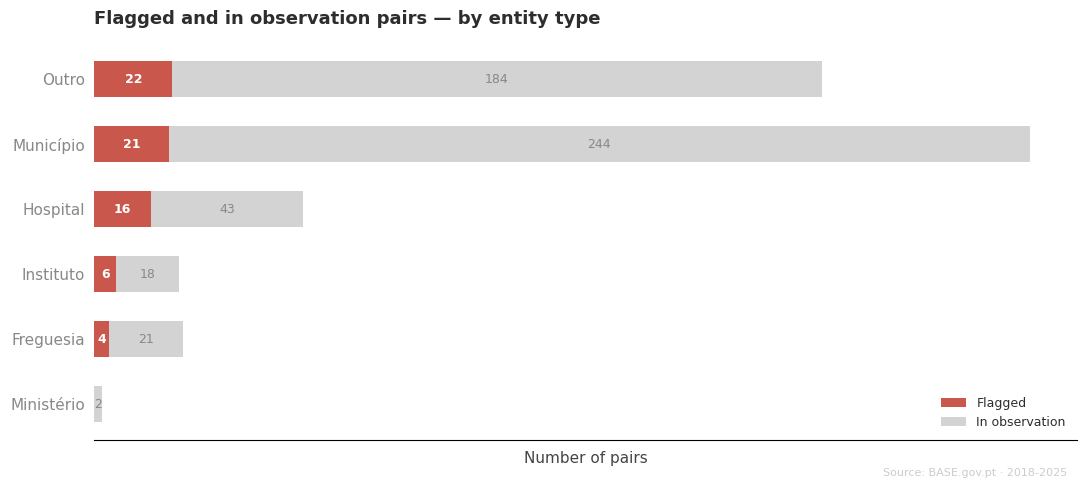

✓ Chart saved to outputs/06_entity_type_distribution.png
✓ entity_type_summary.csv saved


In [8]:
# ── CELL 6 · Flagged Pairs — Distribution by Entity Type ──────────────────────

# ── 6.1 Flagged pairs by entity type
type_flagged = (
    flagged.groupby('entity_type')
    .agg(
        n_pairs       = ('pair_key',    'count'),
        total_value   = ('total_value', 'sum'),
        avg_z_score   = ('z_score',     'mean'),
        avg_near_rate = ('near_rate',   'mean'),
    )
    .reset_index()
    .sort_values('n_pairs', ascending=False)
)

type_total = (
    df.groupby('entity_type')['nif_adjudicante']
    .nunique()
    .reset_index(name='n_entities_total')
)

type_flagged = type_flagged.merge(type_total, on='entity_type', how='left')
type_flagged['flagged_per_entity'] = (
    type_flagged['n_pairs'] / type_flagged['n_entities_total']
)

print("Flagged pairs by entity type:")
print(type_flagged.to_string(index=False))

# ── 6.2 In observation by entity type
type_obs = (
    obs.groupby('entity_type')
    .agg(n_pairs = ('pair_key', 'count'))
    .reset_index()
    .rename(columns={'n_pairs': 'n_obs'})
)

type_combined = type_flagged.merge(type_obs, on='entity_type', how='outer').fillna(0)
type_combined = type_combined.sort_values('n_pairs', ascending=True)

print("\nCombined distribution (flagged + in observation):")
print(type_combined[['entity_type', 'n_pairs', 'n_obs',
                      'avg_z_score', 'avg_near_rate',
                      'flagged_per_entity']].to_string(index=False))

# ── 6.3 Stacked bar chart
fig, ax = plt.subplots(figsize=(11, 5))

bar_flagged = ax.barh(
    type_combined['entity_type'],
    type_combined['n_pairs'],
    color=COLORS['highlight'],
    height=0.55,
    alpha=0.85,
    label='Flagged',
)

bar_obs = ax.barh(
    type_combined['entity_type'],
    type_combined['n_obs'],
    left=type_combined['n_pairs'],
    color=COLORS['base'],
    height=0.55,
    alpha=0.85,
    label='In observation',
)

# Value labels — flagged
for bar in bar_flagged:
    w = bar.get_width()
    if w > 0:
        ax.text(w / 2, bar.get_y() + bar.get_height() / 2,
                f'{int(w)}', va='center', ha='center',
                fontsize=9, color='white', fontweight='bold')

# Value labels — in observation
for bar, flagged_val in zip(bar_obs, type_combined['n_pairs']):
    w = bar.get_width()
    if w > 0:
        ax.text(flagged_val + w / 2, bar.get_y() + bar.get_height() / 2,
                f'{int(w)}', va='center', ha='center',
                fontsize=9, color=COLORS['secondary'])

ax.set_title(
    'Flagged and in observation pairs — by entity type',
    pad=14, loc='left'
)
ax.set_xlabel('Number of pairs', labelpad=8)
ax.set_ylabel('')
ax.set_xticks([])
ax.legend(fontsize=9, frameon=False, loc='lower right')

ax.text(0.99, -0.09, 'Source: BASE.gov.pt · 2018-2025',
        transform=ax.transAxes, fontsize=8,
        color='#cccccc', ha='right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_entity_type_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved to outputs/06_entity_type_distribution.png")

# ── Export for Power BI
type_combined.to_csv(
    os.path.join(OUTPUT_DIR, 'entity_type_summary.csv'), index=False)
print("✓ entity_type_summary.csv saved")

### Interpretation

The pattern is present across every type of public entity in the dataset,
with no type being absent from the flagged or in observation tiers.

**Outro leads in absolute numbers** with 22 flagged pairs, reflecting the
breadth of this category which includes sports clubs, associations, municipal
companies and other public bodies. In relative terms the rate per entity is
negligible given the 5,301 entities in this group.

**Hospitals show the strongest signal per entity**, with 16 flagged pairs
across only 63 unique hospital entities, a flagged rate of 0.25. Roughly 1
in 4 hospital entities has at least one flagged supplier relationship.
Hospitals also show the highest average z-score (3.21) and the highest average
near-threshold rate (81%) among all entity types, meaning that when hospitals
show the pattern, they show it more intensely than any other type.

**Municípios account for 21 flagged pairs** across 375 entities, a rate of
0.06. With 244 pairs in observation, they represent the largest pool of
above-average concentration cases, consistent with their volume and their
reliance on direct award procedures for routine local procurement.

**The presence of Ministérios, Freguesias and Institutos** confirms that the
phenomenon is not sector-specific. Even the smallest administrative units
and the highest levels of government show pairs in observation.

This cross-sectoral distribution is the strongest evidence that the
concentration pattern is a structural response to the law's design rather
than a cultural or operational characteristic of any particular type of
institution. Every type of public entity responds to the same legal incentive
in the same way.

## Section 7 · Summary

This notebook has analysed 1,165,883 public procurement contracts from Portugal
spanning 2018 to 2025, focusing on whether contracts distribute randomly around
the legal thresholds defined by the Public Contracts Code or whether there is
systematic concentration just below them. The year 2017 was retained exclusively
for the temporal analysis as a pre-reform baseline.

**What the data shows:**

At market level, there are 2.7x more contracts in the 5% band immediately below
the €20,000 threshold than the window average, with an abrupt drop immediately
after the limit. The same pattern appears independently at the €75,000 threshold
at 2.7x. Both results return p-values indistinguishable from zero.

The number of contracts in the risk band grew from 1,324 in 2017 to 7,734 in
2025. The inflection point is precise: 2017 shows a ratio of 1.05x, consistent
with a random distribution. From 2018 onwards, when DL 111-B/2017 consolidated
the €20,000 threshold, the ratio jumps to 3.1x and rises every year. The
threshold did not reveal a pre-existing pattern. It created one.

The pattern is present in every district of mainland Portugal and across every
type of public entity, confirming that it is a structural response to the law's
design rather than the behaviour of any specific sector or region.

At the pair level, 69 entity-supplier relationships were flagged as showing
extreme concentration in the 10% risk band below €20,000, with near-threshold
rates between 87.5% and 100% against a market baseline of 5.8%. A further 512
pairs are in observation. Hospitals show the strongest signal per entity, with
roughly 1 in 4 hospital entities having at least one flagged supplier relationship.

**What this does not show:**

This analysis detects statistical patterns, not intent. No finding in this
notebook constitutes evidence of wrongdoing. Every flagged case requires human
review before any conclusion can be drawn.

**What comes next:**

Decree-Law 112/2025 raised the direct award limit from €20,000 to €30,000 from
October 2025 onwards. Data from 2026 onwards will be the most direct test of
this study's hypothesis: if the concentration pattern shifts to the new limit,
it confirms that the threshold itself drives the behaviour and that legislative
design, not individual conduct, is the root cause.

---

**Outputs generated:**
- `market_thresholds.csv` — ratio and statistics for each threshold
- `market_yearly.csv` — contracts in risk band by year (2017-2025)
- `market_geographic.csv` — contracts in risk band by district
- `flagged_pairs.csv` — 69 flagged entity-supplier pairs
- `observation_pairs.csv` — 512 pairs in observation
- `entity_summary.csv` — entity-level aggregation with tier and district
- `entity_type_summary.csv` — distribution of pairs by entity type

**Charts generated:**
- `03_threshold_kde_20k.png` — contract density around the €20,000 threshold
- `03_threshold_kde_75k.png` — contract density around the €75,000 threshold
- `04_temporal_evolution.png` — contracts in risk band 2017 to 2025
- `04_geographic_distribution.png` — contracts in risk band by district
- `05_flagged_pairs.png` — top 15 flagged pairs by near-threshold rate
- `06_entity_type_distribution.png` — flagged and observation pairs by entity type

---

## Publication Graphics — Medium Article

**Output folder:** `outputs/medium/`

**Charts:**
1. `medium_01_threshold_kde.png`
2. `medium_02_temporal_evolution.png`
3. `medium_03_flagged_pairs.png`

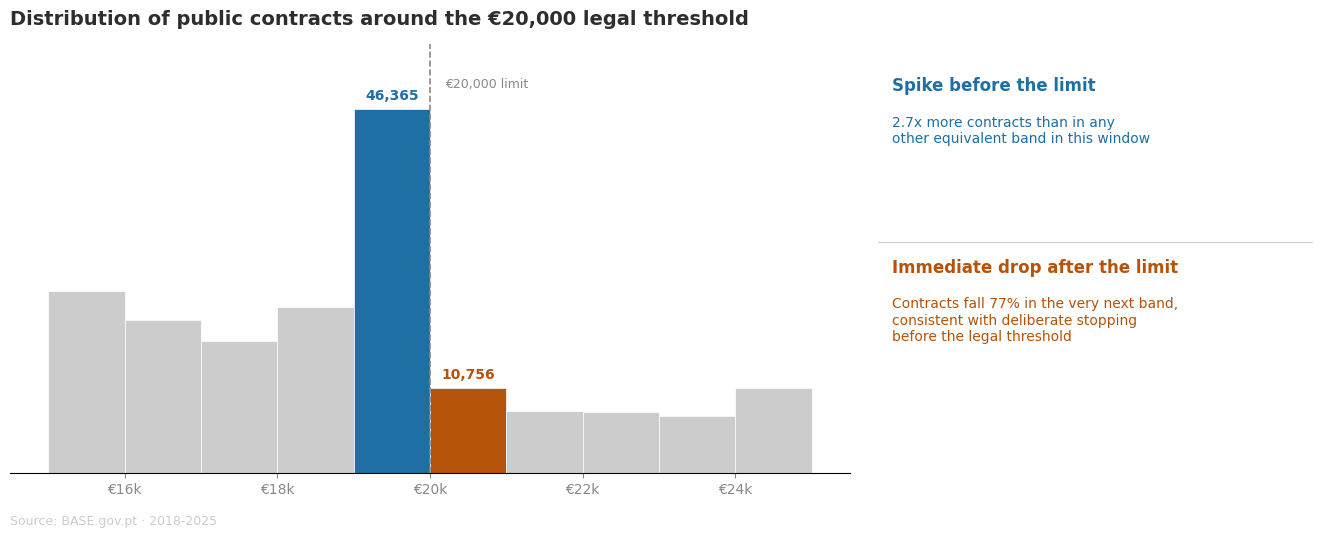

✓ Chart 1 saved to outputs/medium/medium_01_threshold_kde.png


In [16]:
# ── CELL 8 · Publication Graphics — Medium Article ────────────────────────────

MEDIUM_DIR = '../outputs/medium/'
os.makedirs(MEDIUM_DIR, exist_ok=True)

PUB = {
    'base':      '#cccccc',
    'highlight': '#1D6FA4',
    'amber':     '#B45309',
    'secondary': '#888888',
    'dark':      '#2d2d2d',
    'bg':        '#ffffff',
}

plt.rcParams.update({
    'figure.facecolor':   PUB['bg'],
    'axes.facecolor':     PUB['bg'],
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': True,
    'axes.grid':          False,
    'xtick.bottom':       True,
    'ytick.left':         False,
    'font.family':        'sans-serif',
    'font.size':          12,
    'axes.titlesize':     14,
    'axes.titleweight':   'semibold',
    'axes.labelcolor':    '#666666',
    'xtick.color':        '#888888',
    'text.color':         PUB['dark'],
})

# ══════════════════════════════════════════════════════
# CHART 1 — Threshold KDE
# ══════════════════════════════════════════════════════

vals_window = df['precoContratual']
vals_window = vals_window[
    (vals_window >= AD_THRESHOLD * 0.75) &
    (vals_window <= AD_THRESHOLD * 1.25)
]

risk_lo    = AD_THRESHOLD * (1 - MARKET_BAND)
band_width = AD_THRESHOLD - risk_lo

bins          = np.arange(AD_THRESHOLD * 0.75,
                          AD_THRESHOLD * 1.25 + band_width, band_width)
counts, edges = np.histogram(vals_window, bins=bins)

n_risk  = ((df['precoContratual'] >= risk_lo) &
           (df['precoContratual'] <  AD_THRESHOLD)).sum()
n_above = ((df['precoContratual'] >= AD_THRESHOLD) &
           (df['precoContratual'] <  AD_THRESHOLD + band_width)).sum()

avg_per_band = len(vals_window) / int(
    (AD_THRESHOLD * 1.25 - AD_THRESHOLD * 0.75) / band_width)
ratio    = n_risk / avg_per_band
drop_pct = round((1 - n_above / n_risk) * 100)

fig = plt.figure(figsize=(14, 5.5))
ax  = fig.add_axes([0.05, 0.12, 0.60, 0.78])

# Bar colors: blue for risk band, amber for first band above, gray for rest
bar_colors = []
for left in edges[:-1]:
    if risk_lo <= left < AD_THRESHOLD:
        bar_colors.append(PUB['highlight'])
    elif AD_THRESHOLD <= left < AD_THRESHOLD + band_width:
        bar_colors.append(PUB['amber'])
    else:
        bar_colors.append(PUB['base'])

ax.bar(edges[:-1], counts,
       width=band_width,
       color=bar_colors,
       align='edge',
       linewidth=0.5,
       edgecolor='white',
       zorder=2)

ax.axvline(AD_THRESHOLD, color=PUB['secondary'],
           linewidth=1.2, linestyle='--', zorder=3)

ax.text(AD_THRESHOLD + band_width * 0.2,
        counts.max() * 1.06,
        '€20,000 limit',
        fontsize=9, color=PUB['secondary'])

ax.set_ylim(0, counts.max() * 1.18)

# Number above blue bar
risk_mask = (edges[:-1] >= risk_lo) & (edges[:-1] < AD_THRESHOLD)
peak_y    = counts[risk_mask].max()
peak_x    = edges[:-1][risk_mask][counts[risk_mask].argmax()]

ax.text(peak_x + band_width * 0.5, peak_y + counts.max() * 0.02,
        f'{n_risk:,}',
        ha='center', va='bottom', fontsize=10,
        color=PUB['highlight'], fontweight='bold')

# Number above amber bar
above_mask = (edges[:-1] >= AD_THRESHOLD) & \
             (edges[:-1] < AD_THRESHOLD + band_width)
if above_mask.any():
    drop_y = counts[above_mask][0]
    drop_x = edges[:-1][above_mask][0]
    ax.text(drop_x + band_width * 0.5, drop_y + counts.max() * 0.02,
            f'{n_above:,}',
            ha='center', va='bottom', fontsize=10,
            color=PUB['amber'], fontweight='bold')

ax.set_title(
    'Distribution of public contracts around the €20,000 legal threshold',
    pad=14, loc='left'
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticks([])
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
ax.tick_params(axis='x', labelsize=10)

ax.text(0, -0.12,
        'Source: BASE.gov.pt · 2018-2025',
        transform=ax.transAxes, fontsize=9, color='#cccccc')

# Right panel
fig.text(0.68, 0.84,
         'Spike before the limit',
         fontsize=12, color=PUB['highlight'], fontweight='bold',
         transform=fig.transFigure, va='top')

fig.text(0.68, 0.77,
         f'{ratio:.1f}x more contracts than in any\nother equivalent band in this window',
         fontsize=10, color=PUB['highlight'],
         transform=fig.transFigure, va='top')

fig.add_artist(plt.Line2D(
    [0.67, 0.98], [0.54, 0.54],
    transform=fig.transFigure,
    color=PUB['base'], linewidth=0.8))

fig.text(0.68, 0.51,
         'Immediate drop after the limit',
         fontsize=12, color=PUB['amber'], fontweight='bold',
         transform=fig.transFigure, va='top')

fig.text(0.68, 0.44,
         f'Contracts fall {drop_pct}% in the very next band,\nconsistent with deliberate stopping\nbefore the legal threshold',
         fontsize=10, color=PUB['amber'],
         transform=fig.transFigure, va='top')

plt.savefig(os.path.join(MEDIUM_DIR, 'medium_01_threshold_kde.png'),
            dpi=180, bbox_inches='tight')
plt.show()
print("✓ Chart 1 saved to outputs/medium/medium_01_threshold_kde.png")

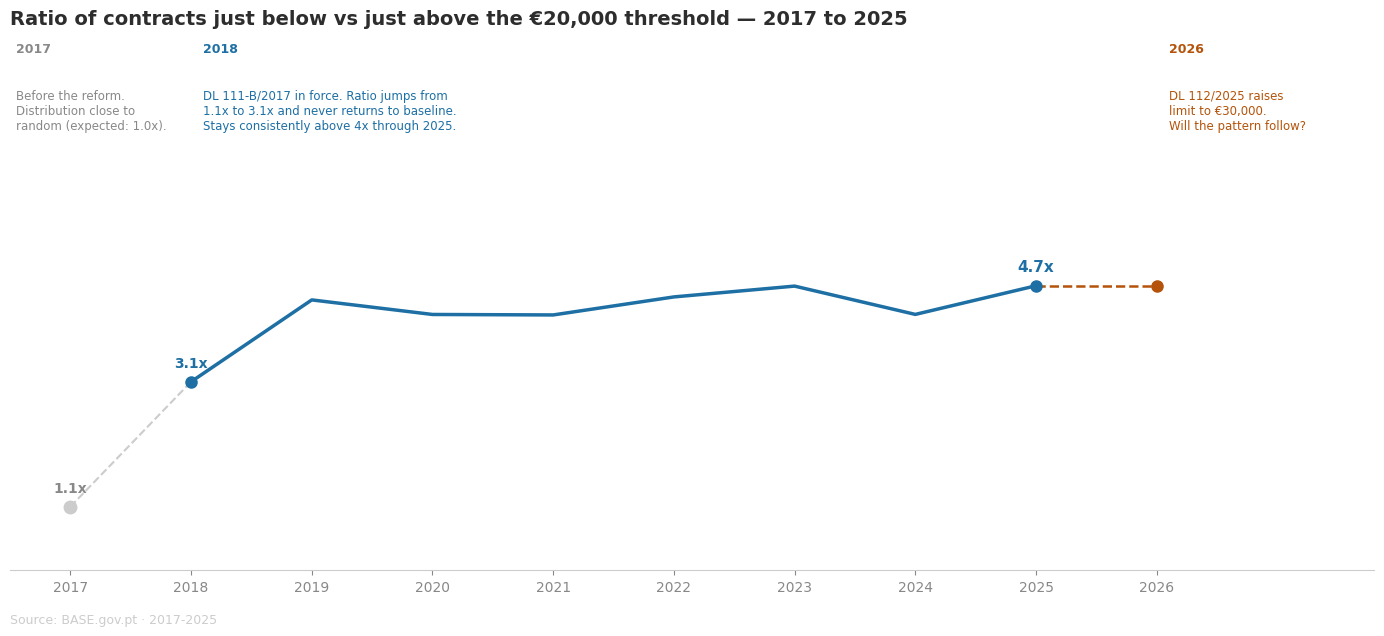

✓ Chart 2 saved to outputs/medium/medium_02_temporal_evolution.png


In [25]:
# ══════════════════════════════════════════════════════
# CHART 2 — Temporal Evolution (ratio)
# ══════════════════════════════════════════════════════

yearly = df_full.groupby('Ano').agg(
    below = ('in_risk_band',    'sum'),
    above = ('above_risk_band', 'sum'),
).reset_index()
yearly['ratio'] = yearly['below'] / yearly['above'].replace(0, 1)

val_2017 = yearly[yearly['Ano'] == 2017]['ratio'].values[0]
val_2018 = yearly[yearly['Ano'] == 2018]['ratio'].values[0]
val_2025 = yearly[yearly['Ano'] == 2025]['ratio'].values[0]

fig, ax = plt.subplots(figsize=(14, 6.5))

pre  = yearly[yearly['Ano'] == 2017]
post = yearly[yearly['Ano'] >= 2018]

# Gray dot for 2017
ax.plot(pre['Ano'], pre['ratio'],
        'o', color=PUB['base'], markersize=9, zorder=3)

# Dashed line 2017 to 2018
ax.plot([2017, 2018],
        [val_2017, val_2018],
        color=PUB['base'], linewidth=1.5,
        linestyle='--', zorder=2)

# Blue line 2018 to 2025 — no markers on intermediate points
ax.plot(post['Ano'], post['ratio'],
        color=PUB['highlight'], linewidth=2.5,
        zorder=3)

# Markers only on 2018 and 2025
ax.plot(2018, val_2018,
        'o', color=PUB['highlight'], markersize=8, zorder=4)
ax.plot(2025, val_2025,
        'o', color=PUB['highlight'], markersize=8, zorder=4)

# Amber dashed line 2025 to 2026
ax.plot([2025, 2026],
        [val_2025, val_2025],
        color=PUB['amber'], linewidth=1.8,
        linestyle='--', zorder=2)

# Amber dot at 2026
ax.plot(2026, val_2025,
        'o', color=PUB['amber'], markersize=8, zorder=4)

ax.set_ylim(0, yearly['ratio'].max() * 1.85)
ax.set_xlim(2016.5, 2027.8)

# Value on 2017
ax.text(2017, val_2017 + yearly['ratio'].max() * 0.04,
        f"{val_2017:.1f}x",
        ha='center', va='bottom', fontsize=10,
        color=PUB['secondary'], fontweight='bold')

# Value on 2018
ax.text(2018, val_2018 + yearly['ratio'].max() * 0.04,
        f"{val_2018:.1f}x",
        ha='center', va='bottom', fontsize=10,
        color=PUB['highlight'], fontweight='bold')

# Value on 2025
ax.text(2025, val_2025 + yearly['ratio'].max() * 0.04,
        f"{val_2025:.1f}x",
        ha='center', va='bottom', fontsize=11,
        color=PUB['highlight'], fontweight='bold')

top = yearly['ratio'].max() * 1.82

# Floating annotation — 2017
ax.text(2016.55, top,
        '2017',
        ha='left', fontsize=9,
        color=PUB['secondary'], fontweight='bold')
ax.text(2016.55, top - yearly['ratio'].max() * 0.13,
        'Before the reform.\nDistribution close to\nrandom (expected: 1.0x).',
        ha='left', fontsize=8.5,
        color=PUB['secondary'], va='top')

# Floating annotation — 2018, all in blue
# Second paragraph includes the continuity message
ax.text(2018.1, top,
        '2018',
        ha='left', fontsize=9,
        color=PUB['highlight'], fontweight='bold')
ax.text(2018.1, top - yearly['ratio'].max() * 0.13,
        'DL 111-B/2017 in force. Ratio jumps from\n'
        '1.1x to 3.1x and never returns to baseline.\n'
        'Stays consistently above 4x through 2025.',
        ha='left', fontsize=8.5,
        color=PUB['highlight'], va='top')

# Floating annotation — 2026, in amber
ax.text(2026.1, top,
        '2026',
        ha='left', fontsize=9,
        color=PUB['amber'], fontweight='bold')
ax.text(2026.1, top - yearly['ratio'].max() * 0.13,
        'DL 112/2025 raises\nlimit to €30,000.\nWill the pattern follow?',
        ha='left', fontsize=8.5,
        color=PUB['amber'], va='top')

# Axes
ax.set_xticks(list(yearly['Ano']) + [2026])
ax.set_xticklabels(
    [str(y) for y in yearly['Ano']] + ['2026'],
    fontsize=10)
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='x', colors='#888888')

ax.set_title(
    'Ratio of contracts just below vs just above the €20,000 threshold — 2017 to 2025',
    pad=14, loc='left'
)

ax.text(0, -0.10,
        'Source: BASE.gov.pt · 2017-2025',
        transform=ax.transAxes, fontsize=9, color='#cccccc')

plt.tight_layout()
plt.savefig(os.path.join(MEDIUM_DIR, 'medium_02_temporal_evolution.png'),
            dpi=180, bbox_inches='tight')
plt.show()
print("✓ Chart 2 saved to outputs/medium/medium_02_temporal_evolution.png")